# Multi-survey injection — Phases 1-4 demo

This notebook walks through the `roman_multisurvey` refactor that lets `streamobs`
inject a single stream carrying **both Roman and Rubin/LSST** photometry, where
each band draws its errors and detection probability from its *own* survey.

| Phase | What changed |
|---|---|
| **1** | `Survey` holds two error curves — a *catalog* (reported `magerr`, drives the S/N cut) and an optional *sample* (true scatter, drives the noise draw). `get_photo_error(..., kind=)` selects between them. |
| **2** | The injector is de-hardcoded off `{r, g}`; column names route through `streamobs.columns`, using a uniform, **always survey-namespaced** `<survey>_<band>_true/_obs/_err` scheme. The S/N cut now applies to **all** injected bands. |
| **3** | `IsochroneModel` is multi-band / multi-survey: masses are drawn **once** (exactly `nstars`) and interpolated into every survey's bands, so the *same physical star* is consistent across surveys. Roman bands are auto-converted Vega→AB. |
| **4** | A single `StreamInjector` accepts one survey **or several**: it does one shared sky placement + one shared true-mag fill, then a per-survey loop writing `<survey>_<band>_obs/_err` and `<survey>_flag_observed`. |

See `docs/source/roman_multisurvey_plan.md` for the full design.


In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import healpy as hp
import yaml
import matplotlib.pyplot as plt

from streamobs.surveys import Survey
from streamobs.model import StreamModel, IsochroneModel
from streamobs.observed import StreamInjector
from streamobs import columns as C

import os
# Resolve the repo root whether the notebook runs from repo root or notebooks/.
REPO = ".." if os.path.exists("../config/scenes/roman_rubin_demo.yaml") else "."
rng = np.random.default_rng(42)


## A runnable stub survey

The real Roman/Rubin maglim maps and CSV tables are **not committed** to this
branch (they live in the git-ignored `data/surveys/`). So that this notebook
runs end-to-end, we use a tiny `StubSurvey` that:

* keeps the **real** `Survey.get_photo_error` (so the Phase-1 two-curve split is
  genuine) and `get_maglim`,
* supplies analytic `log_photo_error_*` curves and a logistic completeness.

The **isochrones are real** (`Marigo2017` via `ugali`). To run against real
surveys, just replace `StubSurvey(...)` with `Survey.load("lsst", release=...)`
etc. — the injector code is identical.


In [2]:
NSIDE = 1  # whole-sky single-pixel maps; enough for a synthetic demo

class StubSurvey(Survey):
    """Minimal Survey: real photo-error machinery, analytic completeness/maps."""

    def __init__(self, name, bands, completeness_band, maglim=27.0,
                 sample_inflation=1.9):
        self.name = name
        self.bands = list(bands)
        self.completeness_band = completeness_band
        self.saturation = {b: 16.0 for b in bands}
        self.sys_error = {b: 0.005 for b in bands}
        self.delta_saturation = -10.0
        self.coeff_extinc = {b: 0.0 for b in bands}
        self.ebv_map = np.zeros(hp.nside2npix(NSIDE))
        self.maglim_maps = {b: np.full(hp.nside2npix(NSIDE), maglim) for b in bands}
        self.coverage = np.ones(hp.nside2npix(NSIDE))  # footprint = whole sky
        # Phase 1: two error curves, both functions of delta_mag = mag - maglim.
        # Catalog = reported error; sample = true scatter (here ~inflation x larger,
        # echoing the Roman DC2 finding that true scatter ~2x reported magerr).
        self.log_photo_error_catalog = lambda dm: np.log10(
            0.01 + 0.10 * np.exp(np.clip(dm, -30, 5)))
        self.log_photo_error_sample = lambda dm: np.log10(
            sample_inflation * (0.01 + 0.10 * np.exp(np.clip(dm, -30, 5))))

    # analytic rolloff: ~1 when bright (mag << maglim), 0.5 at maglim, ->0 fainter
    def get_completeness(self, band, mag, maglim):
        return 1.0 / (1.0 + np.exp((np.asarray(mag) - np.asarray(maglim)) / 0.25))

    def get_detection_efficiency(self, band, mag, maglim):
        return self.get_completeness(band, mag, maglim)

    def get_extinction(self, band, pixel=None):
        return np.zeros(np.size(pixel))

print("StubSurvey ready")

StubSurvey ready


## Phase 1 — sample vs. catalog photometric error

`Survey` now carries two curves. `get_photo_error(kind="catalog")` is the
reported error that becomes `magerr` and drives the S/N cut;
`get_photo_error(kind="sample")` is the *true* scatter used to draw the observed
magnitude. When no sample curve is loaded, `sample` transparently falls back to
`catalog`, so legacy single-curve behaviour is bit-for-bit preserved.


no sample curve -> sample falls back to catalog: True


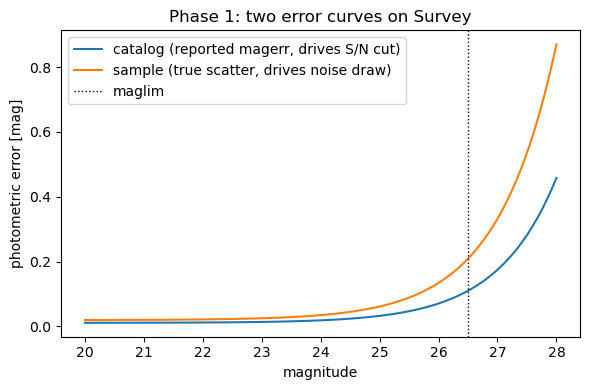

In [3]:
sv = StubSurvey("lsst", ["g", "r"], completeness_band="r", maglim=26.5)
mags = np.linspace(20, 28, 200)
maglim = np.full_like(mags, 26.5)
err_cat = sv.get_photo_error("r", mags, maglim, kind="catalog")
err_smp = sv.get_photo_error("r", mags, maglim, kind="sample")

# A survey with NO sample curve -> sample falls back to catalog (identical)
sv_legacy = StubSurvey("lsst", ["g", "r"], "r", maglim=26.5)
sv_legacy.log_photo_error_sample = None
err_fallback = sv_legacy.get_photo_error("r", mags, maglim, kind="sample")
assert np.allclose(err_fallback, sv_legacy.get_photo_error("r", mags, maglim, kind="catalog"))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mags, err_cat, label='catalog (reported magerr, drives S/N cut)')
ax.plot(mags, err_smp, label='sample (true scatter, drives noise draw)')
ax.axvline(26.5, ls=':', c='k', lw=1, label='maglim')
ax.set_xlabel('magnitude'); ax.set_ylabel('photometric error [mag]')
ax.set_title('Phase 1: two error curves on Survey'); ax.legend(); fig.tight_layout()
print("no sample curve -> sample falls back to catalog:",
      np.allclose(err_fallback, err_cat))

## Phase 2 — arbitrary bands + `columns.py`

The injector no longer hard-codes `{r, g}`. Column names come from
`streamobs.columns`, using one uniform, **always survey-namespaced** convention:
`<survey>_<band>_true` / `<survey>_<band>_obs` / `<survey>_<band>_err` /
`<survey>_flag_observed`. (This intentionally drops the historical `mag_<band>` /
`magerr_<band>` names — not backward compatible.) Below we inject Roman NIR bands
`F106`/`F158` through a **single-survey** `StreamInjector` — impossible under the
old `{r,g}` block — and the output is namespaced by the survey's name (`roman`).


In [4]:
print("namespaced columns:", C.true_col("F158", "roman"), C.obs_col("F158", "roman"),
      C.err_col("F158", "roman"), C.flag_col("roman"))

roman_sv = StubSurvey("roman", ["F106", "F158"], completeness_band="F158", maglim=27.0)
inj = StreamInjector(roman_sv)   # one survey -> namespaced by its name, "roman"
N = 1500
df = pd.DataFrame({
    "ra":  rng.uniform(10, 20, N),
    "dec": rng.uniform(-5, 5, N),
    "roman_F106_true": rng.uniform(20, 28, N),
    "roman_F158_true": rng.uniform(20, 28, N),
})
out = inj.inject(df, bands=["F106", "F158"], seed=1, verbose=False)
print("\ninjected NIR-only bands -> columns:",
      [c for c in out.columns if c.endswith(("_obs", "_err")) or c.endswith("flag_observed")])
print("detected:", int(out.roman_flag_observed.sum()), "/", len(out))

namespaced columns: roman_F158_true roman_F158_obs roman_F158_err roman_flag_observed

injected NIR-only bands -> columns: ['roman_F106_obs', 'roman_F106_err', 'roman_F158_obs', 'roman_F158_err', 'roman_flag_observed']
detected: 1274 / 1500


## Phase 3 — multi-band / multi-survey isochrone (exactly `nstars`)

`IsochroneModel.sample` now draws **exactly** `nstars` (a fixed mass set), for
both single- and multi-survey configs. First, the single-survey path:


In [5]:
single_cfg = {
    "density": {"type": "Uniform", "xmin": -9.0, "xmax": 9.0},
    "track": {"center": {"type": "Constant", "value": 0.0},
               "spread": {"type": "Constant", "value": 0.2}, "sampler": "Gaussian"},
    "distance_modulus": {"center": {"type": "Line", "slope": 0.1, "intercept": 16.5},
                          "spread": {"type": "Constant", "value": 1e-4}, "sampler": "Uniform"},
    "isochrone": {"name": "Marigo2017", "survey": "lsst", "age": 12.0, "z": 0.0006,
                   "band_1": "g", "band_2": "r"},
}
sm = StreamModel(single_cfg)
for n in (5000, 1234):
    assert len(sm.sample(n)) == n
print("single-survey StreamModel.sample returns EXACTLY nstars (5000, 1234) -> OK")

single-survey StreamModel.sample returns EXACTLY nstars (5000, 1234) -> OK


Now the multi-survey scene. One mass draw feeds both surveys, so a star's
LSST and Roman magnitudes describe the *same object*.

multi-survey true columns: ['lsst_g_true', 'lsst_r_true', 'roman_F106_true', 'roman_F158_true']
rows: 4000
corr(lsst_r, roman_F158) = 0.995  (shared masses => tightly correlated)


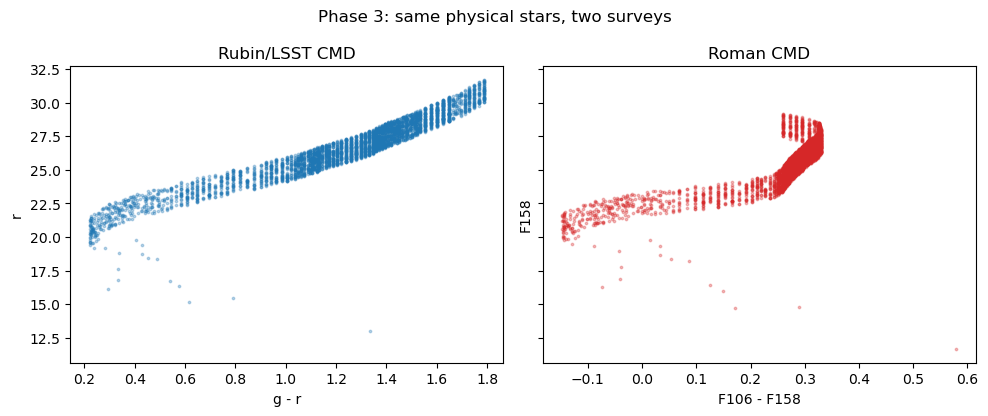

In [6]:
scene = yaml.safe_load(open(f"{REPO}/config/scenes/roman_rubin_demo.yaml"))
sm_ms = StreamModel(scene["stream"])
df_ms = sm_ms.sample(4000)
true_cols = sorted(c for c in df_ms.columns if c.endswith("_true"))
print("multi-survey true columns:", true_cols)
print("rows:", len(df_ms))

rho = np.corrcoef(df_ms["lsst_r_true"], df_ms["roman_F158_true"])[0, 1]
print(f"corr(lsst_r, roman_F158) = {rho:.3f}  (shared masses => tightly correlated)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
axes[0].scatter(df_ms.lsst_g_true - df_ms.lsst_r_true, df_ms.lsst_r_true, s=3, alpha=.3)
axes[0].set_xlabel("g - r"); axes[0].set_ylabel("r"); axes[0].set_title("Rubin/LSST CMD")
axes[0].invert_yaxis()
axes[1].scatter(df_ms.roman_F106_true - df_ms.roman_F158_true, df_ms.roman_F158_true, s=3, alpha=.3, c="C3")
axes[1].set_xlabel("F106 - F158"); axes[1].set_ylabel("F158"); axes[1].set_title("Roman CMD")
axes[1].invert_yaxis()
fig.suptitle("Phase 3: same physical stars, two surveys"); fig.tight_layout()

Roman isochrone magnitudes are **always** converted Vega→AB (no config
flag) using the fixed `ROMAN_VEGA_TO_AB` table, sourced from the
`rubin_roman_object_classification` prototype. Non-Roman bands pass through
unchanged. (A `TODO` in the code notes this ideally belongs in `ugali`.)

In [7]:
from streamobs.model import ROMAN_VEGA_TO_AB
print("Roman Vega->AB offsets (AB = Vega + diff):")
for b, v in ROMAN_VEGA_TO_AB.items():
    print(f"  {b}: +{v}")

iso = StreamModel(scene["stream"]).isochrone   # multi-survey isochrone
x = np.array([20.0, 21.0])
print("\nF158 shift:", (iso._to_ab("F158", x) - x), " (always +1.315)")
print("r    shift:", (iso._to_ab("r", x) - x), " (0 -> non-Roman pass-through)")

Roman Vega->AB offsets (AB = Vega + diff):
  F062: +0.153
  F087: +0.481
  F106: +0.66
  F129: +1.051
  F146: +1.164
  F158: +1.315
  F184: +1.556
  F213: +1.837

F158 shift: [1.315 1.315]  (always +1.315)
r    shift: [0. 0.]  (0 -> non-Roman pass-through)


## Phase 4 — one `StreamInjector`, many surveys

The same `StreamInjector` class accepts a `{namespace: survey}` mapping. It does
one shared sky placement and one shared mass draw, then a per-survey loop writing
each survey's observed columns and flags. Per-survey RNGs come from
`rng.spawn(...)`, so the result is reproducible and independent of survey order.


In [8]:
lsst_sv  = StubSurvey("lsst",  ["g", "r"],      completeness_band="r",    maglim=26.0)
roman_sv = StubSurvey("roman", ["F106", "F158"], completeness_band="F158", maglim=27.0)
msi = StreamInjector({"lsst": lsst_sv, "roman": roman_sv}, primary="lsst")

# Input carries only stream coordinates; everything else is sampled once.
N = 4000
stream_in = pd.DataFrame({"phi1": rng.uniform(-9, 9, N), "phi2": np.zeros(N)})
cat = msi.inject(stream_in.copy(), scene["survey_bands"],
                 stream_config=scene["stream"], seed=7, verbose=False)

print("columns produced:")
for grp in ("lsst", "roman"):
    print(f"  {grp}:", sorted(c for c in cat.columns if c.startswith(grp + "_")))
print(f"\nshared sky placement: ra/dec present = {('ra' in cat) and ('dec' in cat)}")
print(f"lsst detected:  {int(cat.lsst_flag_observed.sum()):5d} / {len(cat)}")
print(f"roman detected: {int(cat.roman_flag_observed.sum()):5d} / {len(cat)}")

columns produced:
  lsst: ['lsst_flag_observed', 'lsst_g_err', 'lsst_g_obs', 'lsst_g_true', 'lsst_r_err', 'lsst_r_obs', 'lsst_r_true']
  roman: ['roman_F106_err', 'roman_F106_obs', 'roman_F106_true', 'roman_F158_err', 'roman_F158_obs', 'roman_F158_true', 'roman_flag_observed']

shared sky placement: ra/dec present = True
lsst detected:   1105 / 4000
roman detected:  3113 / 4000


In [9]:
# Reproducible from seed (given the same true-mag draw)
base = sm_ms.sample(3000)
base["ra"] = rng.uniform(10, 20, len(base)); base["dec"] = rng.uniform(-5, 5, len(base))
a = msi.inject(base.copy(), scene["survey_bands"], seed=11, verbose=False)
b = msi.inject(base.copy(), scene["survey_bands"], seed=11, verbose=False)
c = msi.inject(base.copy(), scene["survey_bands"], seed=22, verbose=False)
print("same seed -> identical obs & flags:",
      a.roman_F158_obs.equals(b.roman_F158_obs) and a.lsst_flag_observed.equals(b.lsst_flag_observed))
print("different seed -> different noise draw:", not a.roman_F158_obs.equals(c.roman_F158_obs))

same seed -> identical obs & flags: True
different seed -> different noise draw: True


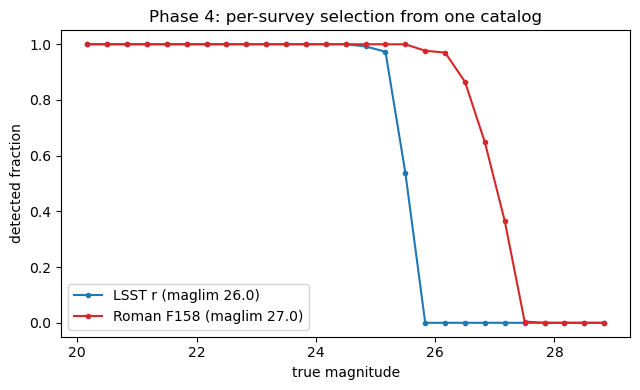

In [10]:
# Detection efficiency vs magnitude, per survey (Roman is deeper here: maglim 27 vs 26)
fig, ax = plt.subplots(figsize=(6.5, 4))
for col, flag, lab, cc in [("lsst_r_true", "lsst_flag_observed", "LSST r (maglim 26.0)", "C0"),
                            ("roman_F158_true", "roman_flag_observed", "Roman F158 (maglim 27.0)", "C3")]:
    m = cat[col].to_numpy(float); f = cat[flag].to_numpy(bool)
    bins = np.linspace(20, 29, 28); idx = np.digitize(m, bins)
    eff = [f[idx == i].mean() if (idx == i).any() else np.nan for i in range(1, len(bins))]
    ax.plot(0.5 * (bins[1:] + bins[:-1]), eff, marker="o", ms=3, label=lab, c=cc)
ax.set_xlabel("true magnitude"); ax.set_ylabel("detected fraction")
ax.set_title("Phase 4: per-survey selection from one catalog"); ax.legend(); fig.tight_layout()

## Notes for real runs

* Swap `StubSurvey(...)` for `Survey.load("lsst", release="dc2")` and the real
  Roman survey once its config/maps land — the injector code is unchanged.
* A band label is used **both** as the ugali isochrone field name and as the key
  into a survey's maglim/photo-error maps, so they must agree (ugali's Roman
  fields are upper-case: `F106`, `F158`, ...).
* **`nstars` is now exactly N** (was an emergent IMF count). This is the agreed
  semantics for both single- and multi-survey configs.
* **Output columns are always survey-namespaced** (`<survey>_<band>_…`), even for
  a single survey — there is no longer an un-namespaced single-survey form.
